# Lecture 2.6 Supplemental Code (Python version)
**Jackson School of Global Affairs**  
**Ardina Hasanbasri (GLBL 5021)**  
Reference: Békés & Kézdi (2021) https://gabors-data-analysis.com/

We will do a difference-in-difference exercise examining airline mergers!  
The data from the textbook has been cleaned for you to save time.

## Setup & Load Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import statsmodels.formula.api as smf
import pyreadstat
import os
import warnings
import pyarrow.parquet as pq
warnings.filterwarnings('ignore')

# Note: linearmodels provides fixed effects / clustered SE support
# pip install linearmodels pyreadstat
from linearmodels.panel import PanelOLS
from linearmodels.iv import absorbing
import rdata
import pyreadr
os.chdir("...")

In [16]:
pwd = os.getcwd()
print(pwd+'\\'+"Lecture_2_6_airline1.parquet")

c:\Users\2025\Documents\Yale\SAY26\GLBL5021\applied-methods-of-analysis-II\examples\Lecture_2_6_Airline_Exercise\Lecture_2_6_Airline_Exercise\Lecture_2_6_airline1.parquet


In [17]:


# Parse the R data file into a hierarchy of Python objects
parsed_data = pyreadr.read_r(pwd+'\\'+"Lecture_2_6_airline1.rds")
df = parsed_data[None]
print(df.head())

KeyboardInterrupt: 

In [ ]:
# Convert the parsed R objects to appropriate Python objects (e.g., pandas DataFrames)
# The default conversion routine handles many standard R types
# 'df' will be the converted Python object
'''
table = pq.read_table(
    pwd+'\\'+"Lecture_2_6_airline1.parquet",
    use_pandas_metadata=False
)
data_balanced = table.to_pandas()
'''
data_balanced = pd.read_parquet(pwd+'\\'+"Lecture_2_6_airline1.parquet")
data_balanced.head()

,origin,finaldest,return,year,airports,return_sym,stops,ptotalAA,ptotalUS,ptotallargest,...,AA_and_US,AA_or_US,market,pass_bef,pass_aft,balanced,treated,untreated,smallmkt,lnavgp
0,ABE,ABI,1.0,2011.0,7.0,1.0,2.0,0.0,0.0,2.000000,...,0.0,0.0,ABE_ABI_1,2.0,5.0,1.0,0.0,1.0,1.0,6.604621
1,ABE,ABI,1.0,2016.0,7.0,1.0,2.0,3.0,0.0,4.000000,...,0.0,1.0,ABE_ABI_1,2.0,5.0,1.0,0.0,1.0,1.0,6.604215
2,ABE,ABQ,0.0,2011.0,3.0,NaN,1.0,0.0,0.0,13.000000,...,0.0,0.0,ABE_ABQ_0,23.0,11.0,1.0,0.0,1.0,1.0,5.818663
3,ABE,ABQ,0.0,2016.0,4.0,NaN,2.0,1.0,0.0,5.000000,...,0.0,1.0,ABE_ABQ_0,23.0,11.0,1.0,0.0,1.0,1.0,6.006129
4,ABE,ABQ,1.0,2011.0,5.0,0.0,1.0,0.0,1.0,38.000001,...,0.0,1.0,ABE_ABQ_1,76.0,33.0,1.0,0.0,0.0,1.0,6.038091


## Step 1: Create the First Difference

In [ ]:
# log, with safe handling of zero/negative prices
data_balanced["lnavgp"] = np.log(data_balanced["avgprice"].where(data_balanced["avgprice"] > 0))

# sort, then group-diff
data_balanced = data_balanced.sort_values(["market", "year"])
data_balanced["d_lnavgp"] = data_balanced.groupby("market")["lnavgp"].diff()

data_balanced[["market", "year", "lnavgp", "d_lnavgp"]].head(10)

,market,year,lnavgp,d_lnavgp
0,ABE_ABI_1,2011.0,6.604621,NaN
1,ABE_ABI_1,2016.0,6.604215,-0.000406
2,ABE_ABQ_0,2011.0,5.818663,NaN
3,ABE_ABQ_0,2016.0,6.006129,0.187466
4,ABE_ABQ_1,2011.0,6.038091,NaN
5,ABE_ABQ_1,2016.0,6.423345,0.385255
6,ABE_ABY_0,2011.0,6.285998,NaN
7,ABE_ABY_0,2016.0,6.068426,-0.217573
8,ABE_ABY_1,2011.0,5.967428,NaN
9,ABE_ABY_1,2016.0,6.398595,0.431167


## Step 2: Simple Diff-in-Diff Regression

In [ ]:
# Basic OLS (no weights)
did = smf.ols('d_lnavgp ~ treated', data=data_balanced).fit()
print(did.summary())

                            OLS Regression Results                            
Dep. Variable:               d_lnavgp   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     86.01
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.82e-20
Time:                        12:22:23   Log-Likelihood:            -1.1394e+05
No. Observations:              112632   AIC:                         2.279e+05
Df Residuals:                  112630   BIC:                         2.279e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0626      0.002     29.918      0.0

In [ ]:
# WLS with pass_bef as weights
did_wls = smf.wls('d_lnavgp ~ treated',
                  data=data_balanced,
                  weights=data_balanced['pass_bef']).fit()
print(did_wls.summary())

                            WLS Regression Results                            
Dep. Variable:               d_lnavgp   R-squared:                       0.053
Model:                            WLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     6263.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:22:30   Log-Likelihood:            -1.9316e+05
No. Observations:              112632   AIC:                         3.863e+05
Df Residuals:                  112630   BIC:                         3.864e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1565      0.002     88.783      0.0

In [ ]:
# WLS with clustered standard errors by market

df = data_balanced.copy()
df = df.replace([np.inf, -np.inf], np.nan)

# Drop rows that will be excluded from the regression anyway
df = df.dropna(subset=["d_lnavgp", "treated", "pass_bef", "market"])
df = df[df["pass_bef"] > 0]

did_clustered = smf.wls(
    "d_lnavgp ~ treated",
    data=df,
    weights=df["pass_bef"]
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["market"]}
)

print(did_clustered.summary())

                            WLS Regression Results                            
Dep. Variable:               d_lnavgp   R-squared:                       0.053
Model:                            WLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     325.6
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.10e-72
Time:                        12:22:56   Log-Likelihood:            -1.9316e+05
No. Observations:              112632   AIC:                         3.863e+05
Df Residuals:                  112630   BIC:                         3.864e+05
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1565      0.007     23.310      0.0

## Step 3: Recreate the Diff-in-Diff Table

In [ ]:
# Control group, 2011 — weighted mean
mean_ctrl_2011 = np.average(
    data_balanced.loc[mask, 'lnavgp'].dropna(),
    weights=data_balanced.loc[mask, 'pass_bef'][data_balanced.loc[mask, 'lnavgp'].notna()]
)
print(f"Control 2011 (weighted):   {mean_ctrl_2011:.4f}")

NameError: name 'mask' is not defined

## Step 4: Diff-in-Diff (Two-Way Fixed Effect Regression with Pooled Cross-Section Data)

In [ ]:
# Two-way FE DiD: lnavgp ~ treated * before
# 'treated*before' includes treated, before, and their interaction
# Build a clean regression frame for did2
df2 = data_balanced.copy().replace([np.inf, -np.inf], np.nan)

df2 = df2.dropna(subset=["lnavgp", "treated", "before", "pass_bef", "market"])
df2 = df2[df2["pass_bef"] > 0]
df2['treatedxb4'] = df2['treated']*df2['before']

did2 = smf.wls(
    "lnavgp ~ treated + before + before*treated",
    data=df2,
    weights=df2["pass_bef"]
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df2["market"]}
)

print("\n=== Level DiD with interaction (WLS + clustered by market) ===")
print(did2.summary())


=== Level DiD with interaction (WLS + clustered by market) ===
                            WLS Regression Results                            
Dep. Variable:                 lnavgp   R-squared:                       0.004
Model:                            WLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     198.0
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          4.17e-128
Time:                        12:28:46   Log-Likelihood:            -5.8160e+05
No. Observations:              225676   AIC:                         1.163e+06
Df Residuals:                  225672   BIC:                         1.163e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

## Step 5: Parallel Trends Assumption — Graphical Check

In [ ]:
table = pq.read_table(
    "Lecture_2_6_airline2.parquet",
    use_pandas_metadata=False
)
data_graph = table.to_pandas()

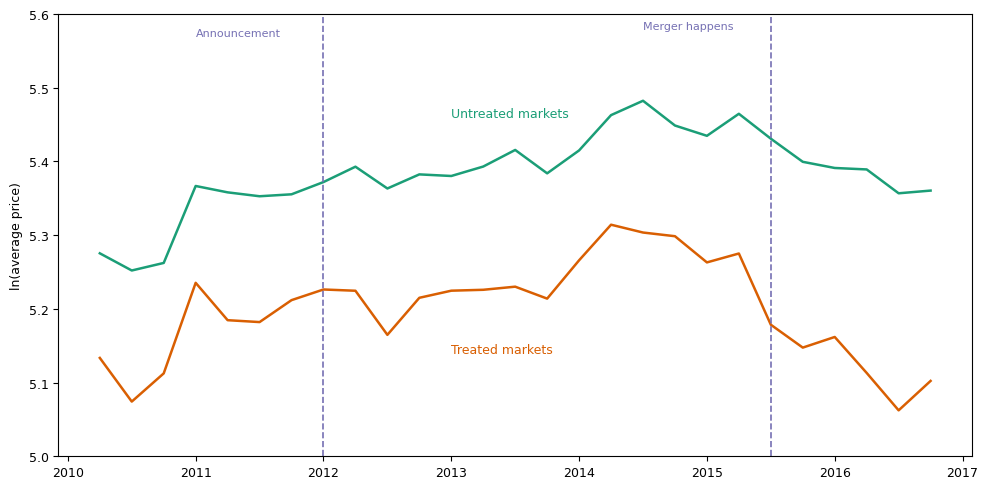

In [ ]:
# Plot parallel trends
color = ['#d95f02', '#1b9e77', '#7570b3']

treated_data   = data_graph[data_graph['treated'] == 1]
untreated_data = data_graph[data_graph['treated'] == 0]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(treated_data['date'],   treated_data['lnavgprice'],   color=color[0], linewidth=1.8, label='Treated markets')
ax.plot(untreated_data['date'], untreated_data['lnavgprice'], color=color[1], linewidth=1.8, label='Untreated markets')

# Vertical lines: announcement and merger
ax.axvline(x=2012.0, color=color[2], linewidth=1.2, linestyle='--')
ax.axvline(x=2015.5, color=color[2], linewidth=1.2, linestyle='--')

# Annotations
ax.text(2013.0, 5.14, 'Treated markets',   fontsize=9, color=color[0])
ax.text(2013.0, 5.46, 'Untreated markets', fontsize=9, color=color[1])
ax.text(2011.0, 5.57, 'Announcement',      fontsize=8, color=color[2])
ax.text(2014.5, 5.58, 'Merger happens',    fontsize=8, color=color[2])

ax.set_ylim(5.0, 5.6)
ax.set_yticks(np.arange(5.0, 5.61, 0.1))
ax.set_ylabel('ln(average price)', fontsize=9)
ax.set_xlabel('', fontsize=9)
ax.tick_params(axis='both', labelsize=9)
ax.legend().set_visible(False)

plt.tight_layout()
plt.savefig('parallel_trends.png', dpi=150)
plt.show()

## Step 6: Diff-in-Diff with Controls

In [ ]:
# Compute pre-period averages of controls within each market
def before_mean(x, col, before_col):
    vals = x.loc[x[before_col] == 1, col]
    return vals.mean() if len(vals) > 0 else np.nan

data_balanced = data_balanced.sort_values(['market', 'year'])

# lnpass_bef: mean of log(passengers) in pre-period
data_balanced['log_passengers'] = np.log(data_balanced['passengers'])
pre_means = (
    data_balanced[data_balanced['before'] == 1]
    .groupby('market')
    .agg(
        lnpass_bef    = ('log_passengers', 'mean'),
        share_bef     = pd.NamedAgg(column='shareAA',       aggfunc=lambda x: (x + data_balanced.loc[x.index, 'shareUS']).mean()),
        sharelarge_bef= ('sharelargest', 'mean')
    )
    .reset_index()
)


KeyboardInterrupt: 

In [ ]:
data_balanced = data_balanced.drop(columns=['lnpass_bef', 'share_bef', 'sharelarge_bef'], errors='ignore')
data_balanced = data_balanced.merge(pre_means, on='market', how='left')

# Regression with controls
formula = 'd_lnavgp ~ treated + lnpass_bef + return + stops + sharelarge_bef'

didctrl = smf.wls(
    formula,
    data=data_balanced,
    weights=data_balanced["pass_bef"]
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df2["market"]}
)

print(didctrl.summary())

NameError: name 'pre_means' is not defined